CÓDIGO RADIACIÓN CUERPO NEGRO

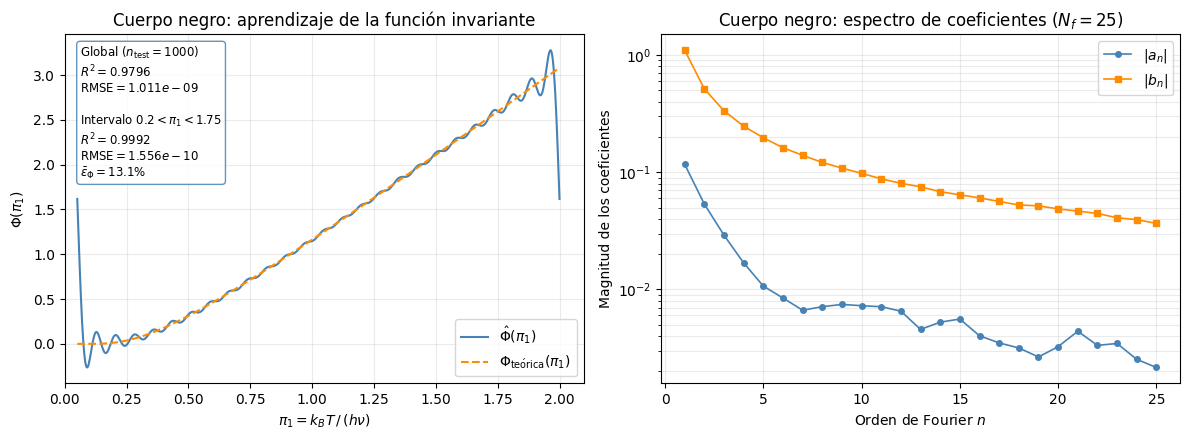

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)

# constantes físicas
h_planck = 6.626e-34    # constante de Planck
c_luz    = 3.0e8        # velocidad de la luz
kB       = 1.381e-23    # constante de Boltzmann

# parametros del experimento
nu_fija   = 1e14                                # frecuencia fija en Hz
Theta_min = int(0.05 * h_planck * nu_fija / kB)  # 239 K
Theta_max = int(2.0  * h_planck * nu_fija / kB)  # 9595 K
N_dat     = 5000
sig_rel   = 0.02
Nf        = 25

# datos sintéticos
Theta_data = rng.uniform(Theta_min, Theta_max, N_dat)
pi1_data   = kB * Theta_data / (h_planck * nu_fija)   # invariante pi = kB*Theta/(h*nu)

def Phi_teorica(pi1):
    return 2.0 / (np.exp(1.0 / pi1) - 1.0)

# prefactor P0 = h*nu^3/c^2
P0       = h_planck * nu_fija**3 / c_luz**2
B_teo    = P0 * Phi_teorica(pi1_data)
ruido    = sig_rel * np.std(B_teo) * rng.standard_normal(N_dat)
B_medido = B_teo + ruido

Phi_medido = B_medido / P0

# normalización del invariante al intervalo [0, 2pi]
pi1_min = pi1_data.min()
pi1_max = pi1_data.max()

def a_u(pi1):
    return 2 * np.pi * (pi1 - pi1_min) / (pi1_max - pi1_min)

# diccionario de Fourier
def build_features(pi1, orden):
    u = a_u(pi1)
    cols = [np.ones(len(pi1))]
    for k in range(1, orden + 1):
        cols.append(np.cos(k * u))
        cols.append(np.sin(k * u))
    return np.column_stack(cols)

X_feat = build_features(pi1_data, Nf)

(X_train, X_test,
 Phi_train, Phi_test,
 pi1_train, pi1_test,
 B_teo_train, B_teo_test) = train_test_split(X_feat, Phi_medido, pi1_data, B_teo,
                                              test_size=0.2, random_state=42)

alphas_grid = np.logspace(-8, 2, 80)
modelo = RidgeCV(alphas=alphas_grid, fit_intercept=False)
modelo.fit(X_train, Phi_train)

coefs_ridge = modelo.coef_
a_n = coefs_ridge[1::2]   # cosenos
b_n = coefs_ridge[2::2]   # senos

# métricas sobre el conjunto de test
Phi_pred     = modelo.predict(X_test)
B_pred       = P0 * Phi_pred
Phi_teo_test = Phi_teorica(pi1_test)

r2_global   = r2_score(B_teo_test, B_pred)
rmse_global = np.sqrt(mean_squared_error(B_teo_test, B_pred))

# métricas para la zona que no tiene el fenómeno de Gibbs (0.2 < pi1 < 1.75)
mask_ok = (pi1_test > 0.2) & (pi1_test < 1.75)

r2_zona = r2_score(B_teo_test[mask_ok], B_pred[mask_ok])
rmse_zona = np.sqrt(mean_squared_error(B_teo_test[mask_ok], B_pred[mask_ok]))
err_phi_zona = np.mean(np.abs(Phi_pred[mask_ok] - Phi_teo_test[mask_ok]) / np.abs(Phi_teo_test[mask_ok])) * 100

# rejilla fina para dibujar la curva completa
pi1_plot  = np.linspace(pi1_min, pi1_max, 800)
Phi_curva = modelo.predict(build_features(pi1_plot, Nf))
Phi_real  = Phi_teorica(pi1_plot)

# Generación de las gráficas
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

#Gráfica de la función invariante 
ax1 = axes[0]
ax1.plot(pi1_plot, Phi_curva, color='steelblue', lw=1.5, label=r'$\hat{\Phi}(\pi_1)$')
ax1.plot(pi1_plot, Phi_real, color='darkorange', lw=1.5, ls='--', label=r'$\Phi_\mathrm{te\acute{o}rica}(\pi_1)$')
ax1.set_xlabel(r'$\pi_1 = k_B T\,/\,(h\nu)$')
ax1.set_ylabel(r'$\Phi(\pi_1)$')
ax1.set_title('Cuerpo negro: aprendizaje de la función invariante')
ax1.set_xlim(left=0)
ax1.legend()
ax1.grid(True, alpha=0.25)

texto_caja = (f'Global ($n_\\mathrm{{test}}={len(X_test)}$)\n'
              f'$R^2 = {r2_global:.4f}$\n'
              f'$\\mathrm{{RMSE}} = {rmse_global:.3e}$\n\n'
              f'Intervalo $0.2 < \\pi_1 < 1.75$\n'
              f'$R^2 = {r2_zona:.4f}$\n'
              f'$\\mathrm{{RMSE}} = {rmse_zona:.3e}$\n'
              f'$\\bar{{\\epsilon}}_\\Phi = {err_phi_zona:.1f}\\%$')
props = dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='steelblue')
ax1.text(0.03, 0.97, texto_caja, transform=ax1.transAxes,
         fontsize=8.5, verticalalignment='top', bbox=props)

#Gráfica de los coeficientes de Fourier
ax2 = axes[1]
ns = np.arange(1, Nf + 1)
ax2.semilogy(ns, np.abs(a_n), 'o-', color='steelblue', ms=4, lw=1.2, label=r'$|a_n|$')
ax2.semilogy(ns, np.abs(b_n), 's-', color='darkorange', ms=4, lw=1.2, label=r'$|b_n|$')
ax2.set_xlabel('Orden de Fourier $n$')
ax2.set_ylabel('Magnitud de los coeficientes')
ax2.set_title(f'Cuerpo negro: espectro de coeficientes ($N_f = {Nf}$)')
ax2.legend()
ax2.grid(True, which='both', alpha=0.25)

plt.tight_layout()
plt.savefig('cuerpo_negro_graficas.png', dpi=150, bbox_inches='tight')
plt.show()